# CreditLens — 01 · Exploratory Data Analysis

EDA answers five questions that shape every later decision:
1. How (im)balanced is the target? → metric + resampling choice
2. Where is the signal? → which features separate defaulters
3. How bad is missingness? → imputation strategy
4. What are the data traps? → e.g. `DAYS_EMPLOYED` anomaly (loader handles it)
5. What lives in the side tables? → motivates Phase 2 aggregation

We reuse the project loaders so the notebook and package never disagree.

## 0 · Setup

In [1]:
import sys; sys.path.insert(0, '..')  # import the creditlens package from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from creditlens.data.load import load_application, load_bureau, load_previous_application
from creditlens.config import TARGET, ID_COL

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (7, 4)

app = load_application()   # DAYS_EMPLOYED == 365243 anomaly already mapped to NaN
print('application:', app.shape)
app.head(3)

application: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 1 · Target balance
`TARGET = 1` = payment difficulty (default-like), `0` = repaid. With ~8% positives, a model that
predicts "everyone repays" is 92% *accurate* and useless — so we score with **ROC AUC** (ranking), not accuracy.

default rate: 0.0807  (8.07%)
TARGET
0    282686
1     24825
Name: count, dtype: int64
imbalance  0:1  =  11.4 : 1


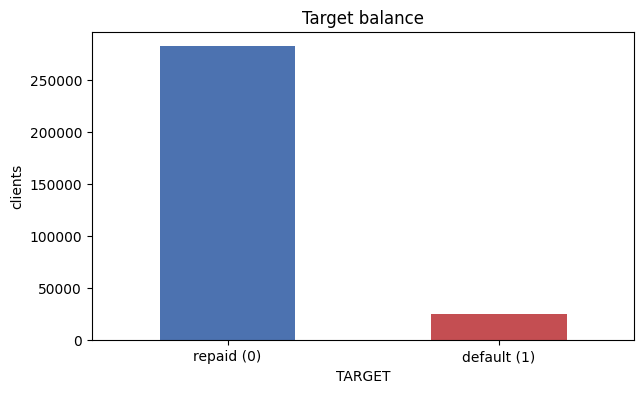

In [2]:
rate = app[TARGET].mean()
print(f'default rate: {rate:.4f}  ({rate*100:.2f}%)')
print(app[TARGET].value_counts())
print(f'imbalance  0:1  =  {(1-rate)/rate:.1f} : 1')

app[TARGET].value_counts().plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.xticks([0, 1], ['repaid (0)', 'default (1)'], rotation=0)
plt.ylabel('clients'); plt.title('Target balance'); plt.show()

## 2 · Missingness
Many building/area columns are mostly empty. We don't drop blindly — *missing* can itself be predictive —
but we note them so Phase 3 imputation is deliberate.

columns with any missing: 68 of 122


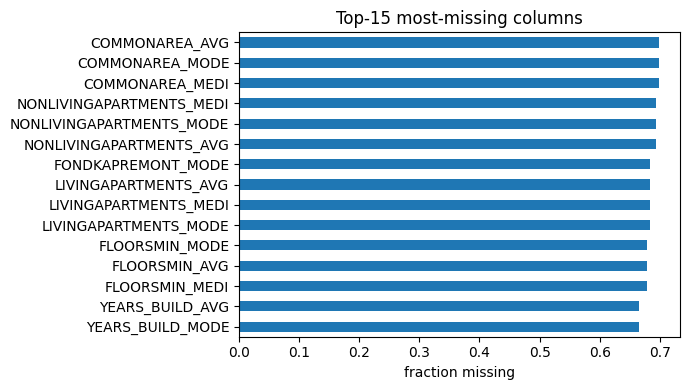

In [3]:
miss = app.isna().mean().sort_values(ascending=False)
print('columns with any missing:', int((miss > 0).sum()), 'of', app.shape[1])
miss.head(15).plot(kind='barh').invert_yaxis()
plt.xlabel('fraction missing'); plt.title('Top-15 most-missing columns'); plt.tight_layout(); plt.show()

## 3 · Where is the signal? EXT_SOURCE_1/2/3
External normalized scores — the strongest predictors here. Negative correlation with `TARGET` means a
higher score → less likely to default. Clear histogram separation = useful feature.

EXT_SOURCE_1   -0.155
EXT_SOURCE_2   -0.160
EXT_SOURCE_3   -0.179
Name: TARGET, dtype: float64


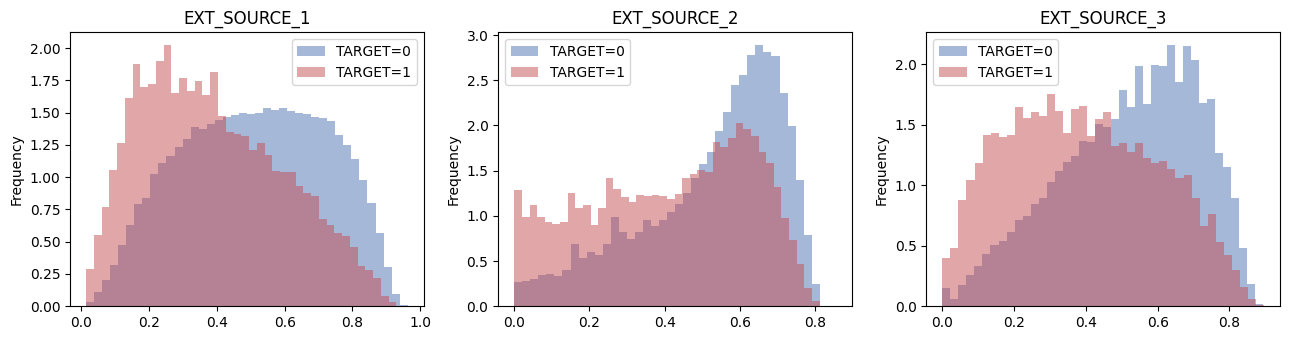

In [4]:
ext = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
print(app[ext + [TARGET]].corr()[TARGET].drop(TARGET).round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, ext):
    for t, c in [(0, '#4C72B0'), (1, '#C44E52')]:
        app.loc[app[TARGET] == t, col].plot(kind='hist', bins=40, density=True,
                                            alpha=0.5, ax=ax, color=c, label=f'TARGET={t}')
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

## 4 · Engineered ratios beat raw amounts
A big loan is fine for a high earner — ratios capture affordability. Preview four (formalized in Phase 2)
and compare their mean by target. `pct_diff` = how much higher the mean is for defaulters.

In [5]:
f = app.copy()
f['AGE_YEARS'] = -f['DAYS_BIRTH'] / 365
f['CREDIT_INCOME_RATIO'] = f['AMT_CREDIT'] / f['AMT_INCOME_TOTAL']
f['ANNUITY_INCOME_RATIO'] = f['AMT_ANNUITY'] / f['AMT_INCOME_TOTAL']
f['CREDIT_TERM'] = f['AMT_ANNUITY'] / f['AMT_CREDIT']

cols = ['AGE_YEARS', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM']
s = f.groupby(TARGET)[cols].mean().T
s.columns = ['repaid', 'default']
s['pct_diff'] = (s['default'] / s['repaid'] - 1) * 100
print(s.round(3))

                      repaid  default  pct_diff
AGE_YEARS             44.214   40.780    -7.766
CREDIT_INCOME_RATIO    3.964    3.887    -1.925
ANNUITY_INCOME_RATIO   0.181    0.185     2.743
CREDIT_TERM            0.054    0.055     1.955


## 5 · Categorical default rates
For a categorical, the useful view is **default rate within each category** (large spread = signal).

In [6]:
for col in ['CODE_GENDER', 'NAME_CONTRACT_TYPE', 'NAME_EDUCATION_TYPE']:
    r = app.groupby(col)[TARGET].agg(['mean', 'count']).sort_values('mean', ascending=False)
    r['mean'] = (r['mean'] * 100).round(2)
    print(f'\n{col} (default % by category):')
    print(r.rename(columns={'mean': 'default_%'}))


CODE_GENDER (default % by category):
             default_%   count
CODE_GENDER                   
M                10.14  105059
F                 7.00  202448
XNA               0.00       4

NAME_CONTRACT_TYPE (default % by category):
                    default_%   count
NAME_CONTRACT_TYPE                   
Cash loans               8.35  278232
Revolving loans          5.48   29279

NAME_EDUCATION_TYPE (default % by category):
                               default_%   count
NAME_EDUCATION_TYPE                             
Lower secondary                    10.93    3816
Secondary / secondary special       8.94  218391
Incomplete higher                   8.48   10277
Higher education                    5.36   74863
Academic degree                     1.83     164


## 6 · Side tables need aggregation
`bureau` and `previous_application` have many rows per applicant — can't join directly. We confirm the
cardinality that forces collapsing each to one row per `SK_ID_CURR` (Phase 2).

In [7]:
bureau = load_bureau()
prev = load_previous_application()
for name, df in [('bureau', bureau), ('previous_application', prev)]:
    per = df.groupby(ID_COL).size()
    print(f'{name}: {len(df):,} rows | {per.shape[0]:,} applicants | '
          f'avg {per.mean():.1f}, max {per.max()} rows per applicant')

bureau: 1,716,428 rows | 305,811 applicants | avg 5.6, max 116 rows per applicant
previous_application: 1,670,214 rows | 338,857 applicants | avg 4.9, max 77 rows per applicant


## 7 · Automated profile report (ydata-profiling)
A one-call overview — types, distributions, correlations, alerts (high-cardinality, high-missing, etc.).
Full data (307k × 122) is slow, so we profile a **sample** in `minimal` mode and save HTML to `reports/`.
We disable wordcloud generation (a ydata bug needs a TrueType font and crashes otherwise).
Treat the report as a fast scan, not a substitute for the targeted analysis above.

In [8]:
from pathlib import Path
from ydata_profiling import ProfileReport

reports = Path('..') / 'reports'
reports.mkdir(exist_ok=True)              # create dir first (else FileNotFoundError)
sample = app.sample(n=20000, random_state=42)
profile = ProfileReport(
    sample, title='CreditLens — application_train (sample)', minimal=True,
    vars={'cat': {'words': False}, 'text': {'words': False}},  # skip wordcloud (Pillow/TrueType bug)
)
profile.to_file(reports / 'eda_profile.html')   # to_file writes; to_html only RETURNS a string
print('wrote', reports / 'eda_profile.html')

/home/jimmy/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/tmp/claude-1000/ipykernel_27349/3734525229.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


/home/jimmy/.local/lib/python3.10/site-packages/ydata_profiling/profile_report.py:365: UserWarning: Try running command: 'pip install --upgrade Pillow' to avoid ValueError
  warnings.warn(


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Summarize dataset:   0%|          | 0/127 [00:00<?, ?it/s, Describe variable: SK_ID_CURR]

...

Render HTML: 100%|██████████| 1/1 [00:00<00:00,  1.90it/s]

Render HTML: 100%|██████████| 1/1 [00:00<00:00,  1.89it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 182.24it/s]

wrote ../reports/eda_profile.html


## Takeaways → Phase 2
- **Metric:** ROC AUC (8% positives). Also report KS + calibration (credit needs trustworthy PD).
- **Top features:** `EXT_SOURCE_1/2/3` (negatively correlated with default).
- **Build ratios:** credit/income, annuity/income, credit-term, age — affordability beats raw amounts.
- **Imputation needed:** many high-missing columns; treat 'missing' as informative.
- **Aggregate side tables:** collapse `bureau` & `previous_application` to one row per `SK_ID_CURR`.

Next: `02_features.ipynb` → `creditlens/data/features.py`.